In [24]:
from sklearn.metrics import mutual_info_score, adjusted_mutual_info_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import ansari, wilcoxon, ttest_ind, kruskal
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

## Preprocesamiento

In [25]:
datos = pd.read_csv("YouTube.csv")
datos

,web-scraper-order,web-scraper-start-url,rank,Youtuber,subscribers,video views,video count,category,started
0,1699959846-1,https://us.youtubers.me/colombia/all/top-1000-...,1,Shakira,"44,900,000","28,569,817,682",338,People & Blogs,2005
1,1699959846-2,https://us.youtubers.me/colombia/all/top-1000-...,2,shakiraVEVO,"18,400,000","26,289,897,314",204,Music,2009
2,1699959846-3,https://us.youtubers.me/colombia/all/top-1000-...,3,J Balvin,"34,200,000","23,286,669,108",164,Music,2011
3,1699959846-4,https://us.youtubers.me/colombia/all/top-1000-...,4,jbalvinVEVO,"13,200,000","21,075,464,369",238,Music,2010
4,1699959846-5,https://us.youtubers.me/colombia/all/top-1000-...,5,KAROL G,"33,400,000","20,909,054,370",151,Music,2013
...,...,...,...,...,...,...,...,...,...
995,1699959846-996,https://us.youtubers.me/colombia/all/top-1000-...,996,Los Parcheros,"39,600","18,832,516",127,Sports,2015
996,1699959846-997,https://us.youtubers.me/colombia/all/top-1000-...,997,ZONA K-POP,"354,000","18,827,611",139,People & Blogs,2014
997,1699959846-998,https://us.youtubers.me/colombia/all/top-1000-...,998,Mario Tutoriales,"88,500","18,807,635",121,Science & Technology,2016
998,1699959846-999,https://us.youtubers.me/colombia/all/top-1000-...,999,Checho 1996 Loquendero,"42,000","18,794,740",191,People & Blogs,2012


In [26]:
X = datos.drop(['web-scraper-order', 'web-scraper-start-url', 'Youtuber', 'category'], axis=1).copy()
for col in ['subscribers', 'video views', 'video count']:
    X[col] = X[col].str.replace(',', '').astype(float)
X = X.dropna()
X

,rank,subscribers,video views,video count,started
0,1,44900000.0,2.856982e+10,338.0,2005
1,2,18400000.0,2.628990e+10,204.0,2009
2,3,34200000.0,2.328667e+10,164.0,2011
3,4,13200000.0,2.107546e+10,238.0,2010
4,5,33400000.0,2.090905e+10,151.0,2013
...,...,...,...,...,...
995,996,39600.0,1.883252e+07,127.0,2015
996,997,354000.0,1.882761e+07,139.0,2014
997,998,88500.0,1.880764e+07,121.0,2016
998,999,42000.0,1.879474e+07,191.0,2012


In [27]:

scale = MinMaxScaler()

X = scale.fit_transform(X)
pd.DataFrame(X).describe()

pca = PCA(n_components=2).fit(X)
X_pca = pca.transform(X)

In [28]:
# Simulación de los datos de las dos muestras
sample1 = np.random.exponential(np.sqrt(20), size=5000)
sample2 = np.random.exponential(np.sqrt(30), size=5000)

# Realizar el test de Ansari-Bradley
statistic, p_value = ansari(sample1, sample2)

# Imprimir los resultados
print("Estadístico de prueba:", statistic)
print("Valor p:", p_value)
alpha=0.05

if p_value > alpha:
    print('No rechazamos H0: Las dos muestras tienen la misma varianza')
else:
    print('Rechazamos H0: Las dos muestras tienen varianzas diferentes')

Estadístico de prueba: 12711574.0
Valor p: 0.003769064693980835
Rechazamos H0: Las dos muestras tienen varianzas diferentes


In [29]:
# Datos de las dos muestras
sample1 = np.random.exponential(np.sqrt(20), size=5000)
sample2 = np.random.exponential(np.sqrt(30), size=5000)

# Concatenar las muestras en un solo array
combined_samples = np.concatenate((sample1, sample2))

# Calcular la diferencia de varianzas observada
obs_diff_var = np.var(sample1) - np.var(sample2)

# Número de permutaciones a realizar
num_permutations = 5000

# Inicializar un array para almacenar las diferencias de varianzas permutadas
perm_diff_vars = np.zeros(num_permutations)

# Realizar las permutaciones y calcular las diferencias de varianzas permutadas
for i in range(num_permutations):
    np.random.shuffle(combined_samples)
    perm_sample1 = combined_samples[:len(sample1)]
    perm_sample2 = combined_samples[len(sample1):]
    perm_diff_vars[i] = np.var(perm_sample1) - np.var(perm_sample2)

# Calcular el valor p
p_value = np.sum(np.abs(perm_diff_vars) >= np.abs(obs_diff_var)) / num_permutations

alpha = 0.05
if p_value > alpha:
    print('No rechazamos H0: Las dos muestras tienen la misma varianza')
else:
    print('Rechazamos H0: Las dos muestras tienen varianzas diferentes')

Rechazamos H0: Las dos muestras tienen varianzas diferentes


In [30]:
df = pd.DataFrame({
    "Dog i": range(1, 8),
    "X_i": [480, 130, 250, 310, 280, 1450, 280],
    "Y_i": [350, 200, 240, 290, 90, 370, 240]
})

print("Datos")
print(df)

stat, p = wilcoxon(df.X_i, df.Y_i, alternative='less')

print()
print("*" * 20)
print('statistics={:.3f}, p={:.3f}'.format(stat, p))

# Interpretación
alpha = 0.05

if p > alpha:
    print('No rechazamos HO: No hay efecto de la estimulación del nervio vago sobre la secreción de insulina')
else:
    print("Rechazamos HO: La estimulación del nervio vago aumenta el nivel sanguíneo de insulina inmunorreactiva")

Datos
   Dog i   X_i  Y_i
0      1   480  350
1      2   130  200
2      3   250  240
3      4   310  290
4      5   280   90
5      6  1450  370
6      7   280  240

********************
statistics=24.000, p=0.961
No rechazamos HO: No hay efecto de la estimulación del nervio vago sobre la secreción de insulina


In [31]:
# Crear DataFrame
df = pd.DataFrame({
    'Child ID': range(1, 8),
    'Before': [425,533,362,628,463,427,449],
    'After': [349,400,520,490,574,427,435]
})

# Imprimir datos
print("Datos")
print(df)

# Filtrar solo los datos con diferencias
df = df[df['Before'] != df['After']]

# Calcular la prueba de Wilcoxon
stat, p = wilcoxon(df.Before, df.After, alternative='less')

# Imprimir resultados
print()
print("*"*20)
print('statistics={:.3f}, p={:.3f}'.format(stat, p))

# Interpretación
alpha=0.05

if p > alpha:
    print('No rechazamos HO: La terapia con hormona de crecimiento no afecta la hidroxiprolina insoluble al calor con la piel')
else:
    print('Rechazamos H0: La terapia con hormona de crecimiento aumenta la hidroxiprolina insoluble al calor con la piel')

Datos
   Child ID  Before  After
0         1     425    349
1         2     533    400
2         3     362    520
3         4     628    490
4         5     463    574
5         6     427    427
6         7     449    435

********************
statistics=12.000, p=0.656
No rechazamos HO: La terapia con hormona de crecimiento no afecta la hidroxiprolina insoluble al calor con la piel


In [32]:
# Crear un DataFrame
df = pd.DataFrame({
    'Subject_i': range(1, 7),
    'X_1': [10.5, 19.5, 7.5, 4.0, 4.5, 2.0],
    'Y_1': [18.5, 24.5, 11.0, 2.5, 5.5, 3.5]
})

# Imprimir los datos
print("Datos")
print(df)

# Eliminar los sujetos con valores faltantes
df = df.dropna()

# Realizar la prueba de Wilcoxon
stat, p = wilcoxon(df.X_1, df.Y_1, alternative='less')

# Imprimir los resultados
print()
print("*" * 20)
print("statistics={:.3f}, p={:.3f}".format(stat, p))

# Interpretación
alpha = 0.05

if p > alpha:
    print("No rechazamos HO: La práctica y el entrenamiento no afecta la susceptibilidad hipnótica")

else:
    print("Rechazamos H0: La susceptibiliad hipnótica puede aumentar con la práctica y el entrenamiento")

Datos
   Subject_i   X_1   Y_1
0          1  10.5  18.5
1          2  19.5  24.5
2          3   7.5  11.0
3          4   4.0   2.5
4          5   4.5   5.5
5          6   2.0   3.5

********************
statistics=2.500, p=0.062
No rechazamos HO: La práctica y el entrenamiento no afecta la susceptibilidad hipnótica


In [33]:
df = pd.DataFrame({
    'Subject_i': range(1, 15),
    'X_i': [270, 150, 270, 420, 202, 255, 165, 220, 305, 210, 240, 300, 380, 781],
    'Y_i': [525, 570, 198, 395, 370, 210, 490, 250, 360, 285, 630, 385, 195, 295]
})

df['Diff'] = df['Y_i'] - df['X_i']

statistic, p_value = wilcoxon(df['Diff'])

print("Estadístico de prueba:", statistic)
print("Valor p:", p_value)

alpha = 0.05
if p_value > alpha:
    print('No rechazamos HO: Una dosis de 600 mg de aspirina no tiene efecto en el tiempo de sangrado')
else:
    print('Rechazamos H0: Una dosis de 600 mg de aspirina generalmente provoca un aumento en el tiempo de sangrado!')

Estadístico de prueba: 32.0
Valor p: 0.216552734375
No rechazamos HO: Una dosis de 600 mg de aspirina no tiene efecto en el tiempo de sangrado


In [34]:
# Crear el DataFrame con los datos
df = pd.DataFrame({
    'Subject_i': range(1, 15),
    'X_1': [270, 150, 270, 420, 202, 255, 165, 220, 305, 210, 240, 300, 380, 781],
    'Y_1': [525, 570, 198, 395, 370, 210, 490, 250, 360, 285, 630, 385, 195, 295]
})

# Calcular las medias de las dos muestras
mean_x = np.mean(df['X_1'])
mean_y = np.mean(df['Y_1'])

# Realizar la prueba t
t_stat, p_value = ttest_ind(df['X_1'], df['Y_1'])

# Imprimir los resultados
print("Estadístico t:", t_stat)
print("Valor p:", p_value)

alpha=0.05
if p_value > alpha:
    print('No rechazamos HO: Una dosis de 600 mg de aspirina no tiene efecto en el tiempo de sangrado')
else:
    print('Rechazamos HO: Una dosis de 600 mg de aspirina generalmente provoca un aumento en el tiempo de sangrado!')

Estadístico t: -1.2479588837210345
Valor p: 0.22316868354268088
No rechazamos HO: Una dosis de 600 mg de aspirina no tiene efecto en el tiempo de sangrado


In [35]:
karate_kid_watchers = [
    37, 39, 30, 7, 13, 139, 45, 25, 16, 146, 94, 16, 23, 1, 290, 169, 62, 145, 36, 20, 13
]

olympics_watchers = [
    12, 44, 34, 14, 9, 19, 156, 23, 13, 11, 47, 26, 14, 33, 15, 62, 5, 8, 0, 154, 146
]

estadistico, valor_p = wilcoxon(karate_kid_watchers, olympics_watchers)

print("Estadístico del test:", estadistico)
print("Valor p:", valor_p)

alpha = 0.05
if valor_p > alpha:
    print('No Rechazamos H0: no hay suficiente evidencia para concluir que existen diferencias significativas en la tolerancia a la violencia entre los dos grupos de niños.')
else:
    print('Rechazamos HO: los niños que vieron la televisión violenta tienden a tardar más en buscar ayuda (son más tolerantes) en comparación con los niños que vieron la televisión no violenta.')

Estadístico del test: 82.5
Valor p: 0.2513448130867494
No Rechazamos H0: no hay suficiente evidencia para concluir que existen diferencias significativas en la tolerancia a la violencia entre los dos grupos de niños.


In [36]:
# Datos para cada especie de pino
scotch_pine = [
52.2, 56.4, 57.1, 46.9, 49.1, 52.5, 63.0, 52.0, 61.1, 55.3, 46.2, 57.2
]

blue_spruce = [
46.7, 60.5, 58.9, 82.9, 65.8, 93.3, 66.9, 70.9, 73.7, 65.8, 90.2, 68.9
]

white_pine = [
75.2, 63.7, 73.2, 66.2, 67.4, 69.4, 70.4, 72.3, 63.6, 61.9, 74.4, 70.1
]

# Realizar el test de Kruskal-Wallis
statistic, p_value = kruskal(scotch_pine, blue_spruce, white_pine)

# Imprimir los resultados
print("Test statistic:", statistic)
print("p-value:", p_value)

alpha=0.05
if p_value > alpha:
  print("""No Rechazamos H0: No hay suficiente evidencia para concluir que existen
diferencias significativas en las longitudes intersticiales medianas
entre las ramas secundarias de las tres especies de pino.""")

else:
  print("""
Rechazamos H0: existen diferencias significativas en las longitudes
intersticiales medianas entre las ramas secundarias de las tres especies
de pino.""")


Test statistic: 18.60299480842664
p-value: 9.128743489420963e-05

Rechazamos H0: existen diferencias significativas en las longitudes
intersticiales medianas entre las ramas secundarias de las tres especies
de pino.


# DBScan

Parametros `eps` y `min_samples`.

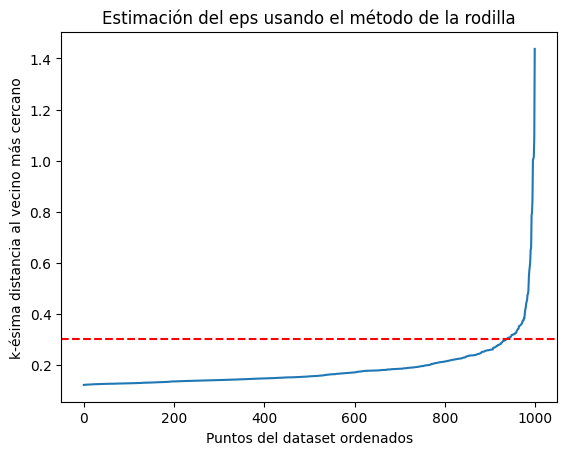

In [37]:
N = 100
nbrs = NearestNeighbors(n_neighbors=N).fit(X)
distances, indices = nbrs.kneighbors(X)

distances = np.sort(distances, axis=0)
distances = distances[:,N-1]
plt.plot(distances)
plt.axhline(y=0.30, color='r', linestyle='--') #Ajuste el valor para y
plt.title('Estimación del eps usando el método de la rodilla')
plt.xlabel('Puntos del dataset ordenados')
plt.ylabel('k-ésima distancia al vecino más cercano');

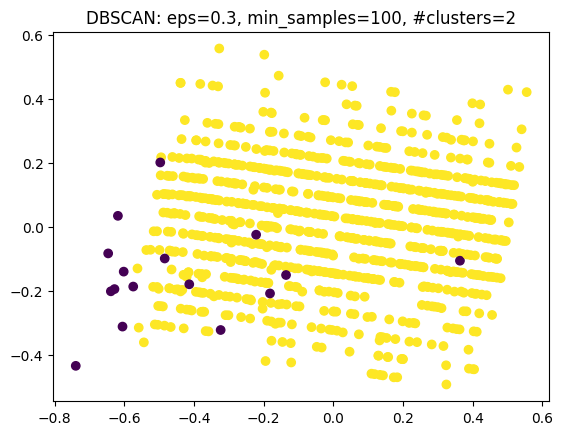

In [38]:
eps = 0.3
min_samples = 100

dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
dbscan_labels = dbscan.labels_

plt.scatter(X_pca[:,0], X_pca[:,1], c=dbscan_labels)
plt.title(f"DBSCAN: eps={eps}, min_samples={min_samples}, #clusters={len(np.unique(dbscan.labels_))}")
plt.show()


#Habría que seguir explorando los parámetros, en este caso solo identificamos un cluster (+ ruido)

In [39]:
np.unique(dbscan.labels_)

array([-1,  0])

# Evaluación

## Matriz de similitud (proximidad)


In [40]:
def sim_matrix(features, labels):
    useful_labels = labels >= 0

    # primero ordenamos los datos en base al cluster que pertencen
    indices = np.argsort(labels[useful_labels])
    sorted_features = features[useful_labels][indices]

    # calculamos las distancias entre todos los puntos
    d = euclidean_distances(sorted_features, sorted_features)
    return d

def plot(data, labels):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20,5))
    ax1.scatter(data[:,0], data[:,1], c=labels)

    dist = sim_matrix(data, labels)
    im = ax2.imshow(dist, cmap="jet")
    fig.colorbar(im, ax=ax2)

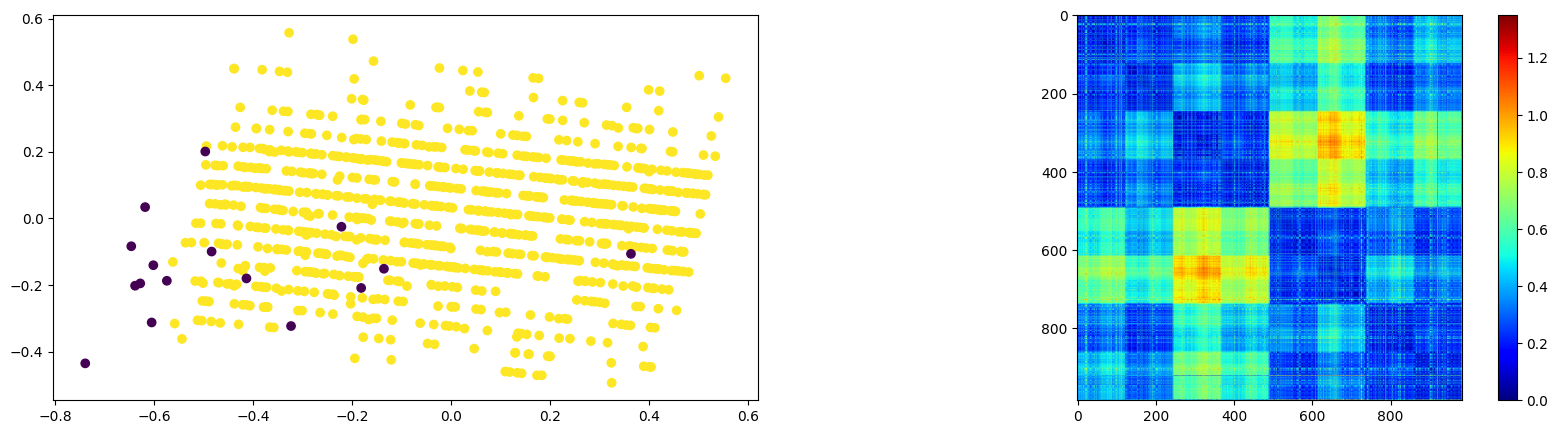

In [41]:
plot(X_pca, dbscan_labels) #solo identificamos 1 cluster
plt.show()